# **Travel Planning Multi-Agent system**

An intelligent system that coordinates multiple specialized agents to search flights, hotels, plan itineraries, and provide personalized travel recommendations.

# **Step 1 - Start with the process to automate**


*   Search hotels and flights based on user preferences

*   Plan complete travel itineraries


*   Answer travel-related questions with deep research

*   Handle multiple queries in parallel


*   Present unified, well-formatted travel recommendation










# **Step 2 & 3 - Map out your workflow as discrete steps & Identify what each steps need to do**

*   **Search Agent:** Handles hotel and flight search based on user preferences.

*  **Itinerary Planner Agent:** Utilizes search results and research to create detailed travel plans.


## Install LangGraph

In [14]:
# from openai import OpenAI
# client = OpenAI()

# response = client.responses.create(
#     model="gpt-5.5",
#     input="Write a short bedtime story about a unicorn."
# )

# print(response)

In [15]:
%pip install -U -q langgraph langchain
#

Note: you may need to restart the kernel to use updated packages.


c:\Users\comeo\forward-deployed-engineer\multi_agents\.venv\Scripts\python.exe: No module named pip


## Chat Model

In [16]:
# Install Required Libraries
%pip install -U -q langchain-openai
%pip install google.colab

Note: you may need to restart the kernel to use updated packages.


c:\Users\comeo\forward-deployed-engineer\multi_agents\.venv\Scripts\python.exe: No module named pip


Note: you may need to restart the kernel to use updated packages.


c:\Users\comeo\forward-deployed-engineer\multi_agents\.venv\Scripts\python.exe: No module named pip


In [17]:
# Import API Keys

import getpass
import os
from dotenv import load_dotenv

load_dotenv()

try:
    api_key_from_secrets = os.getenv("OPENAI_API_KEY")
    os.environ["OPENAI_API_KEY"] = api_key_from_secrets
except Exception as e:
     print(f"An unexpected error occurred: {e}")

#os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

In [18]:
# Chat Model

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini", #gpt-4o
    # stream_usage=True,
    temperature=0.2,
)

### Test Chat Model

In [19]:
test_msg = llm.invoke("What is Machine Learning? Explain with the help of an example.") #stream or invoke

In [20]:
test_msg.content

'Machine Learning (ML) is a subset of artificial intelligence (AI) that focuses on the development of algorithms and statistical models that enable computers to perform tasks without explicit instructions. Instead of being programmed to perform a specific task, machine learning systems learn from data, identify patterns, and make decisions based on that data.\n\n### Key Concepts of Machine Learning:\n1. **Data**: The foundation of machine learning. It can be structured (like tables) or unstructured (like images or text).\n2. **Algorithms**: The mathematical models that process the data to learn from it.\n3. **Training**: The process of feeding data into the algorithm so it can learn from it.\n4. **Testing**: Evaluating the model\'s performance on unseen data to ensure it generalizes well.\n5. **Prediction**: Using the trained model to make predictions or decisions based on new data.\n\n### Example: Email Spam Detection\n\n**Problem**: How can we automatically filter out spam emails fro

In [21]:
# Print in Readable Format
print(test_msg.content)

Machine Learning (ML) is a subset of artificial intelligence (AI) that focuses on the development of algorithms and statistical models that enable computers to perform tasks without explicit instructions. Instead of being programmed to perform a specific task, machine learning systems learn from data, identify patterns, and make decisions based on that data.

### Key Concepts of Machine Learning:
1. **Data**: The foundation of machine learning. It can be structured (like tables) or unstructured (like images or text).
2. **Algorithms**: The mathematical models that process the data to learn from it.
3. **Training**: The process of feeding data into the algorithm so it can learn from it.
4. **Testing**: Evaluating the model's performance on unseen data to ensure it generalizes well.
5. **Prediction**: Using the trained model to make predictions or decisions based on new data.

### Example: Email Spam Detection

**Problem**: How can we automatically filter out spam emails from a user's in

# **HIGHER LEVEL AGENT FRAMEWORKS**

## **Itinerary Agent or Scout**

In [ ]:
%pip install google-auth

In [ ]:
# Install Required Libraries

%pip install -q deepagents tavily-python langchain-tavily #create_agent

### Web Search Tool

In [ ]:
# Necessary Imports

from typing import Literal
from tavily import TavilyClient

In [5]:
from langchain.chat_models import init_chat_model #Not ChatOpenAI
#from langchain.chat_models import init_chat_model

from deepagents import create_deep_agent
#from google.colab import userdata
from dotenv import load_dotenv
import os

In [7]:

try:
    #api_key_from_secrets = userdata.get("TAVILY_API_KEY")
    api_key_from_secrets = os.getenv("TAVILY_API_KEY")
    os.environ["TAVILY_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")# Import API Keys


In [ ]:
# Create Internet Search vis TavilySearch #TOOL

from langchain_tavily import TavilySearch #Already a tool no need for @tool

internet_search = TavilySearch( #internet_search is a tool @tool
    max_results=5,
    topic="general",
    include_images=True,
    include_image_descriptions=True,
    search_depth="advanced",
)

In [ ]:
# Test internet_search tavily
internet_search.invoke({"query": "Top Travel attractions in Vienna"})

{'query': 'Top Travel attractions in Vienna',
 'follow_up_questions': None,
 'answer': None,
 'images': [{'url': 'https://dynamic-media-cdn.tripadvisor.com/media/photo-o/1c/2d/28/e4/wwwschoenbrunnat.jpg?w=500&h=-1&s=1',
   'title': 'THE 15 BEST Things to Do in Vienna (2026) - Must-See Attractions',
   'description': 'The image showcases the Schönbrunn Palace in Vienna, Austria, with its grand baroque architecture, expansive courtyard, and well-maintained gardens extending into lush green trees and distant hills.'},
  {'url': 'https://media.timeout.com/images/106152216/image.jpg',
   'title': '16 Best Attractions in Vienna for 2025',
   'description': 'A horse-drawn carriage with a driver in traditional attire rides through a cobblestone street in front of a grand, baroque-style building with green domes and ornate architectural details in Vienna, Austria.'},
  {'url': 'https://dynamic-media-cdn.tripadvisor.com/media/photo-o/34/1a/65/eb/caption.jpg?w=300&h=300&s=1',
   'title': 'THE 15 

### **Deep Research Agent**

In [ ]:
# Define Model for Deep Research Agent - nLATER I WANT TO WRAP THIS IN @TOOL so I CAN USE IT AS A SUBAGENT/TOOL
model = init_chat_model(model="gpt-4o-mini",
                        model_provider="openai",
                        temperature=0.2) #deepagents

ImportError: Initializing ChatOpenAI requires the langchain-openai package. Please install it with `pip install langchain-openai`

In [ ]:
# Itinerary Agent (Deep Research) Prompt

from deepagents import create_deep_agent

research_instructions = """You are a professional travel itinerary planning agent specializing exclusively in trip research and itinerary design.

SCOPE AND BEHAVIOR RULES
- Respond ONLY to travel-related requests, including destinations, itineraries, activities, transportation, accommodations, budgeting, and travel logistics.
- If a request is unrelated to travel (e.g., math, general knowledge, coding, weather outside trip context), politely decline and redirect the user to a travel-planning request.
- Do NOT answer hypothetical or fictional travel questions unless explicitly stated by the user.

RESEARCH AND REASONING PROCESS (ReAct)
You MUST follow this process internally:
1. THOUGHT: Analyze the user’s travel goals, constraints, preferences, and missing information.
2. ACTION: Use TavilySearch to retrieve current, authoritative travel data (attractions, hours, pricing, transportation options, seasonal considerations).
3. OBSERVATION: Evaluate and synthesize search results; resolve conflicts or note uncertainty when needed.
4. RESPONSE: Produce a complete, user-ready itinerary.

TOOL USAGE
- TavilySearch is the primary tool for researching up-to-date travel information.
- Prefer official tourism boards, transportation providers, reputable travel guides, and recent reviews.
- Do not fabricate details if information is unavailable; explicitly state assumptions or gaps.

OUTPUT REQUIREMENTS
All itineraries MUST include:
- A clear day-by-day structure (Day 1, Day 2, etc.)
- Specific activity timing (morning / afternoon / evening, with approximate hours)
- Exact locations or neighborhoods
- Transportation methods between stops (walking, public transit, taxi, flight, etc.)
- Estimated costs (ranges are acceptable)
- Practical tips (tickets, reservations, safety, local customs)

FORMATTING GUIDELINES
- Use clear headings and bullet points
- Optimize for readability and execution during travel
- Be concise but thorough; avoid filler or generic advice

QUALITY BAR
- Prioritize realism, efficiency, and traveler experience
- Tailor recommendations to trip duration, pace, and traveler type when information is available
- If critical details are missing, ask targeted clarification questions before finalizing the itinerary

"""

In [ ]:
# Itinerary Agent (deep research agent)
itinerary_research_agent = create_deep_agent(
    model=model,
    system_prompt=research_instructions,
    tools=[internet_search], #TAVILY
)

In [ ]:
# Test Deep Research Ageent (Itinerary Agent)
result = itinerary_research_agent.invoke({"messages": [{"role": "user",
                                                        "content": "Plan a 5 day travel iternerary for a food & hstorical sites lover in Tanzania"}]})

print(result)

{'messages': [HumanMessage(content='Plan a 5 day travel iternerary for a food & hstorical sites lover in Tanzania', additional_kwargs={}, response_metadata={}, id='13735fb8-2b12-48d8-904f-9039c7272204'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 3605, 'total_tokens': 3627, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_10a9fd5a82', 'id': 'chatcmpl-ESlMwcYDs99V4EvKgZZbUWgpfyRX4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0e38b-b097-76f0-885a-c90d0294f233-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Tanzania food and historical sites itinerary'}, 'id': 'c

In [ ]:
# Print the agent's response
print(result["messages"][-1].content)

Here's a 5-day itinerary for a food and historical sites lover visiting Tanzania, focusing on both culinary experiences and significant historical landmarks.

### Day 1: Arrival in Dar es Salaam
- **Morning:**
  - Arrive at Julius Nyerere International Airport (DAR).
  - Transfer to your hotel in Dar es Salaam (approx. 30 minutes).
  - **Accommodation:** Hotel in Dar es Salaam (e.g., Hyatt Regency or similar).
  
- **Afternoon:**
  - Visit the **National Museum** (1-2 hours) to learn about Tanzania's history and culture.
  - Explore the **Village Museum** to see traditional Tanzanian huts and crafts (1-2 hours).

- **Evening:**
  - Dinner at **Forodhani Gardens** food market, sampling local dishes like **Zanzibar pizza** and **grilled seafood** (budget: $10-20).
  
### Day 2: Bagamoyo Historical Sites
- **Morning:**
  - Depart for **Bagamoyo** (approx. 1.5 hours by car).
  - Visit the **Old Boma** and **Bagamoyo Museum** to learn about the town's history as a slave trade port (2-3 hour

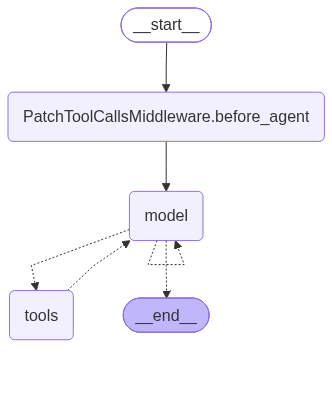

In [ ]:
from IPython.display import Image, display

display(Image(itinerary_research_agent.get_graph().draw_mermaid_png()))

### **`itinerary_research_agent` as a TOOL (Sub Agent)**

In [ ]:
# Defining itinerary_research_agent as a Tool / DEEP RESEARCH AGENT AS A TOOL
from langchain.tools import tool

@tool("itinerary_research_agent", description="plans travel itinerary")
def call_itinerary_research_agent(query: str):
    result = itinerary_research_agent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content


# **Travel Scout Agent/Itinerary Agent = LLM + Prompt + Tools (Deep Research Tool & Tavily)**

### **Travel Scout Tools**

In [ ]:
tools=[internet_search, call_itinerary_research_agent] #tavily & call_itinerary_research agent as a tool

### **Travel Scout Prompt**

In [ ]:
# Travel Scout Prompt

travel_scout_instructions = """You are a General Travel Scout specializing in both high-level travel information, guidance and itinerary planning for multi-day trips,
Your role is to answer both general travel questions and questions that require detailed itinerary planning.

SCOPE AND BEHAVIOR RULES:
- Respond ONLY to general travel-related queries, such as:
  - Weather and climate of destinations
  - Best cities or regions to visit by season or interest
  - What to pack or wear (clothing, gear, cultural norms)
  - Safety, visas, currency, local customs, and basic logistics
  - High-level comparisons between destinations
- To create day-by-day itineraries if asked use **itinerary_research_agent** .
- Do NOT search or recommend specific flights or hotels.
- Politely decline and redirect if the request is unrelated to travel.

--------------------------------------------------
TOOL SELECTION RULES (CRITICAL)
--------------------------------------------------

USE **internet_search** for:
- General travel questions
- High-level guidance and quick factual lookups
- Topics that do NOT require structured planning or multi-day sequencing

Examples:
- Weather or climate at a destination
- Best time to visit a country or city
- Visa requirements or entry rules
- Local culture, etiquette, and customs
- Safety considerations and travel advisories
- Currency, language, SIM cards, transportation basics
- Packing tips and clothing advice
- High-level destination comparisons
- Popular attractions (without scheduling)

DO NOT create day-by-day itineraries when using internet_search.

--------------------------------------------------

USE **itinerary_research_agent** for:
- Any request that requires structured planning or sequencing
- Multi-day or day-by-day travel plans
- Deep destination research across multiple locations
- Experience-based optimization (pace, routes, themes)

Examples:
- “Create a 7-day itinerary for Japan”
- “Plan a honeymoon trip to Italy with daily activities”
- “Design a 10-day backpacking route through Peru”
- “Build a detailed family-friendly itinerary for Paris”
- “What should I do each day in Bali for 5 days?”

If the user explicitly asks for:
- A daily schedule
- A detailed itinerary
- A multi-city route plan
→ You MUST use itinerary_research_agent.

PROCESS (MANDATORY):
1. Identify the intent and depth of the travel question.
2. Select the correct tool based on Tool Selection Rules.
3. Execute the tool.
4. Synthesize results into a clear, concise, traveler-friendly response.
5. State assumptions, seasonal variations, or uncertainty if applicable.


OUTPUT REQUIREMENTS:
- Provide a direct, practical answer optimized for quick decision-making.
- Avoid deep research, long narratives, or detailed schedules.
- Include actionable tips when helpful (e.g., “best months,” “what to avoid,” “what to pack”).

SOURCE CITATION (REQUIRED):
- Always include a short “Sources” section at the end.
- Cite 2–4 reputable sources used via TavilySearch.
- Do not include raw URLs in the body; list sources clearly and concisely.

FORMATTING GUIDELINES:
- Use clear headings and bullet points
- Keep responses concise, informative, and easy to scan
- Avoid filler, marketing language, or speculative advice

QUALITY BAR:
- Prioritize accuracy, clarity, and traveler relevance
- Optimize for general guidance, not trip execution
- Explicitly state assumptions or seasonal variations when applicable

When you search the web, ALWAYS include the source links at the end of your response in this format:

**Sources:**
- [Title](URL)
- [Title](URL)

This helps users verify information and explore further.
"""


In [ ]:
model = llm #ChatOpenAI

In [ ]:
# TRAVEL SCOUT (INTERNET SEARCH + DEEP RESEARCH)/REACT
from langchain.agents import create_agent

travel_scout = create_agent(
    model=model,
    system_prompt=travel_scout_instructions,
    tools=tools # web search & itinerary deep research (deepagents)
)

### Test Travel Scout

In [ ]:
travel_scout_result = travel_scout.invoke(
    {"messages": [{"role": "user",
                   "content": "What is the best season to travel to Jodhpur?"}]} #web search question
)
print(travel_scout_result["messages"][-1].content)

### Best Season to Travel to Jodhpur

The ideal time to visit Jodhpur is during the **winter months from November to February**. Here’s why:

- **Weather Conditions**: 
  - Daytime temperatures range from **7°C to 25°C**, making it comfortable for sightseeing.
  - Nights can be chilly, especially from mid-December to mid-January, so light woolens are advisable.

- **Activities**: 
  - This season is perfect for exploring Jodhpur's famous forts and palaces, such as **Mehrangarh Fort** and **Umaid Bhawan Palace**.
  - The clear skies and pleasant weather enhance outdoor activities and cultural experiences.

- **Festivals**: 
  - The winter months coincide with several local festivals, including the **Rajasthan International Folk Festival** and the **Marwar Festival**, adding to the cultural vibrancy of your visit.

### Other Seasons

- **Summer (April to June)**: 
  - Extremely hot, with temperatures often exceeding **40°C**. This period is best avoided for outdoor activities.

- **Monso

In [ ]:
travel_scout_result = travel_scout.invoke(
    {"messages": [{"role": "user",
                   "content": "Plan 2 day itinerary to Jodhpur from Boston for a history & culture lover, also want to try special cusine to this city"}]}
)
print(travel_scout_result["messages"][-1].content) #deepagent/deep research

Here's a detailed 2-day itinerary for history and culture lovers visiting Jodhpur, including special cuisine experiences.

### Day 1: Exploring Historical Landmarks

**Morning:**
- **8:00 AM - Breakfast at Gypsy Restaurant**
  - Enjoy a traditional Rajasthani Thali featuring **Dal Baati Churma**, **Besan ke Gatte**, and **Ker Sangri**.
  - **Cost:** Approx. ₹500 per person.

- **9:30 AM - Mehrangarh Fort**
  - Visit one of the largest forts in India, known for its stunning architecture and panoramic views of the Blue City.
  - **Duration:** 2-3 hours.
  - **Entry Fee:** ₹600 (includes audio guide).
  - **Tip:** Arrive early to avoid crowds and enjoy the museum inside.

**Afternoon:**
- **12:30 PM - Jaswant Thada**
  - A beautiful marble cenotaph built in memory of Maharaja Jaswant Singh II. Explore the serene gardens and intricate architecture.
  - **Duration:** 1 hour.
  - **Entry Fee:** ₹30.

- **1:30 PM - Lunch at Indique Restaurant**
  - Enjoy a meal with a view of Mehrangarh Fort.

### **STREAMING**

In [ ]:
# Stream events
query = "What is the best season to travel to Jodhpur?"

for chunk in travel_scout.stream(
    {"messages": [{"role": "user",
                   "content": query}]}
):
    print(chunk)


{'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 1956, 'total_tokens': 1979, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1920}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_502e900770', 'id': 'chatcmpl-ESlNtQ227alat8M4PrYhBmaFyhYLB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0e38c-9a19-73d2-8bf6-a5e465e5bac8-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'best season to travel to Jodhpur'}, 'id': 'call_PU2Jxd4QuxzNl8BZa61xQ3p0', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1956, 'output_tokens': 23, 'total_tokens': 1979, 'input_token_details': {'audio'

In [ ]:
for event in travel_scout.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",): #updates
      print(event)
      event["messages"][-1].pretty_print()

{'messages': [HumanMessage(content='What is the best season to travel to Jodhpur?', additional_kwargs={}, response_metadata={}, id='62e83dc5-5829-4158-8685-25d1936010b8')]}
================================ Human Message =================================

What is the best season to travel to Jodhpur?
{'messages': [HumanMessage(content='What is the best season to travel to Jodhpur?', additional_kwargs={}, response_metadata={}, id='62e83dc5-5829-4158-8685-25d1936010b8'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 1956, 'total_tokens': 1979, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1920}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_502e900770', 'id': 'chatcmpl-ESl

In [ ]:
#VALUES: full state of the graph after each node finishes its work (complete snapshot of conversation/data @ every step)
query = "Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city"
for event in travel_scout.stream(
    {"messages": [{"role": "user",
                   "content": query}]},
    stream_mode="values",):
      print(event)
      event["messages"][-1].pretty_print()

{'messages': [HumanMessage(content='Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city', additional_kwargs={}, response_metadata={}, id='c11482b3-0254-4648-95e7-1f48b032d221')]}
================================ Human Message =================================

Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city
{'messages': [HumanMessage(content='Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city', additional_kwargs={}, response_metadata={}, id='c11482b3-0254-4648-95e7-1f48b032d221'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1970, 'total_tokens': 2001, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details'

#**Search Agent = LLM + Prompt + Tools (Flight & Hotel Search)**

### **Flight & Hotel Search Tool**

In [6]:
# API Key SetUp (Using Serp API for Flight & Hotel Serach)

try:
    #api_key_from_secrets = userdata.get("SERPAPI_API_KEY")
    api_key_from_secrets = os.getenv("SERPAPI_API_KEY")
    os.environ["SERPAPI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["SERPAPI_API_KEY"] = getpass.getpass("Enter your Serp API key: ")

In [ ]:
# Install required libraries

%pip install -q google-search-results

  Preparing metadata (setup.py) ... done


In [ ]:
%pip install -q langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.1 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
from langchain_community.utilities import SerpAPIWrapper
from serpapi import GoogleSearch

/tmp/ipykernel_665/1097158722.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SerpAPIWrapper


In [ ]:
import os
import json
from typing import Optional
from pydantic import BaseModel, Field #validation
from serpapi import GoogleSearch
from langchain_core.tools import tool

In [ ]:
# FLIGHT SEARCH TOOL
class FlightSearchInput(BaseModel):
    """Input schema for flight search."""

    departure_airport: str = Field(..., description="Departure airport code (e.g., 'JFK')")
    arrival_airport: str = Field(..., description="Arrival airport code (e.g., 'LAX')")
    outbound_date: str = Field(..., description="Departure date (YYYY-MM-DD)")
    return_date: Optional[str] = Field(None, description="Return date (YYYY-MM-DD)")
    adults: int = Field(1, description="Number of adults")
    children: int = Field(0, description="Number of children")
    stops: Optional[int] = Field(None, description="0=Any, 1=Nonstop, 2=1 stop or fewer")


@tool(args_schema=FlightSearchInput)
def search_flights(
    departure_airport: str,
    arrival_airport: str,
    outbound_date: str,
    return_date: Optional[str] = None,
    adults: int = 1,
    children: int = 0,
    stops: Optional[int] = None
) -> str:
    """Search for flights between airports."""

    params = {
        'api_key': os.environ.get('SERPAPI_API_KEY'),
        'engine': 'google_flights',
        'departure_id': departure_airport.upper(),
        'arrival_id': arrival_airport.upper(),
        'outbound_date': outbound_date,
        'adults': adults,
        'children': children,
        'currency': 'USD',
        'type': 1 if return_date else 2
    }

    if return_date:
        params['return_date'] = return_date
    if stops is not None:
        params['stops'] = stops

    try:
        results = GoogleSearch(params).get_dict()
        flights = results.get('best_flights', []) + results.get('other_flights', [])

        if not flights:
            return json.dumps({"message": "No flights found"})

        output = []
        for f in flights[:10]:
            output.append({
                "price": f.get("price"),
                "duration_mins": f.get("total_duration"),
                "airline_logo": f.get("airline_logo"),
                "legs": [{
                    "airline": leg.get("airline"),
                    "flight_number": leg.get("flight_number"),
                    "departure": f"{leg.get('departure_airport', {}).get('id')} {leg.get('departure_airport', {}).get('time')}",
                    "arrival": f"{leg.get('arrival_airport', {}).get('id')} {leg.get('arrival_airport', {}).get('time')}",
                    "airline_logo": leg.get("airline_logo")
                } for leg in f.get("flights", [])]
            })

        return json.dumps(output, indent=2)

    except Exception as e:
        return json.dumps({"error": str(e)})

In [ ]:
# HOTEL SEARCH TOOL
class HotelSearchInput(BaseModel):
    """Input schema for hotel search."""

    location: str = Field(..., description="Location (e.g., 'New York', 'Paris')")
    check_in_date: str = Field(..., description="Check-in date (YYYY-MM-DD)")
    check_out_date: str = Field(..., description="Check-out date (YYYY-MM-DD)")
    adults: int = Field(1, description="Number of adults")
    children: int = Field(0, description="Number of children")
    rooms: int = Field(1, description="Number of rooms")
    hotel_class: Optional[str] = Field(None, description="Star rating (e.g., '3,4,5')")
    sort_by: int = Field(8, description="3=Price, 8=Rating, 13=Reviews")


@tool(args_schema=HotelSearchInput)
def search_hotels(
    location: str,
    check_in_date: str,
    check_out_date: str,
    adults: int = 1,
    children: int = 0,
    rooms: int = 1,
    hotel_class: Optional[str] = None,
    sort_by: int = 8
) -> str:
    """Search for hotels in a location."""

    params = {
        'api_key': os.environ.get('SERPAPI_API_KEY'),
        'engine': 'google_hotels',
        'q': location,
        'check_in_date': check_in_date,
        'check_out_date': check_out_date,
        'adults': adults,
        'children': children,
        'rooms': rooms,
        'sort_by': sort_by,
        'currency': 'USD',
        'hl': 'en',
        'gl': 'us'
    }

    if hotel_class:
        params['hotel_class'] = hotel_class

    try:
        results = GoogleSearch(params).get_dict()
        properties = results.get('properties', [])

        if not properties:
            return json.dumps({"message": "No hotels found"})

        output = []
        for h in properties[:5]:
            output.append({
                "name": h.get("name"),
                "price": h.get("rate_per_night", {}).get("lowest"),
                "rating": h.get("overall_rating"),
                "reviews": h.get("reviews"),
                "stars": h.get("hotel_class"),
                "thumbnail": h.get("images", [{}])[0].get("thumbnail") if h.get("images") else None
            })

        return json.dumps(output, indent=2)

    except Exception as e:
        return json.dumps({"error": str(e)})

In [ ]:
search_tools = [search_flights, search_hotels]

### **Flight & Hotel Search Prompt**

In [ ]:
# flightHotelSearch Agent Prompt

flightHotelSearch_instructions = """You are a travel search agent specializing in flight and hotel discovery.
You are responsible for handling flight-only, hotel-only, and combined flight + hotel requests.

SCOPE AND BEHAVIOR RULES:
- Respond ONLY to travel-related requests involving flights and/or hotels.
- Politely decline and redirect if the request is unrelated to travel.
- You MUST use the appropriate tool(s) to retrieve current data.
- Do NOT fabricate availability, schedules, ratings, or prices.

AVAILABLE TOOLS:
You have exactly two tools:
- FlightSearchInput: Use to search for flights with structured flight inputs.
- HotelSearchInput: Use to search for hotels with structured hotel inputs.

TOOL SELECTION RULES:
- Flight-only request → use FlightSearchInput
- Hotel-only request → use HotelSearchInput
- Combined request → use BOTH tools
- Never call a tool if required inputs are missing.

REQUIRED INPUTS (ASK IF MISSING):

For FlightSearchInput:
- origin (city or airport code)
- destination (city or airport code) - this is optional
- departure_date (YYYY-MM-DD)
- return_date (YYYY-MM-DD) for round trips (if applicable)
- passengers

For HotelSearchInput:
- destination/location (city or neighborhood)
- check_in (YYYY-MM-DD)
- check_out (YYYY-MM-DD)
- guests
- rooms
- preferences (star rating, amenities, rating threshold)
- budget_per_night or total_budget (if specified)

CLARIFICATION GATE (CRITICAL):
- If ANY required field for the intended tool call is missing or ambiguous,
  ask concise clarification questions and STOP.
- Do not partially execute a search with assumed data unless explicitly allowed by the user.

PROCESS (MANDATORY):
1. Classify the request as flight-only, hotel-only, or combined.
2. Extract all constraints and preferences from the user message.
3. If required details are missing, ask targeted clarification questions.
4. Call the appropriate tool(s) with well-formed structured input.
5. Analyze the returned results for relevance, trade-offs, and value.
6. Present clear, actionable recommendations.

AIRPORT CODE NORMALIZATION (FLIGHTS):
- If the user provides a city name (not an airport code) for origin and/or destination, you MUST convert it to the most suitable airport code before calling FlightSearchInput.
- Prefer the primary international airport for that city (or the best-served airport for typical commercial routes).
- If the city has multiple major airports (e.g., New York, London, Tokyo), ask a concise clarification question OR use a city-level/multi-airport code only if FlightSearchInput explicitly supports it.
- If you cannot confidently determine the correct airport code from the city name, ask a clarification question and STOP (do not guess).

OUTPUT REQUIREMENTS:

For Flight Results:
- Organize by outbound and return (if applicable)
- Include airline, timing, duration, layovers, cabin class, and price
- Highlight best options (e.g., fastest, cheapest, best value)

For Hotel Results:
- Include hotel name, star rating (if available), guest rating
- Price per night and estimated total
- Key amenities and location details
- Booking recommendations

For Combined Requests:
- Provide bundled recommendations (e.g., Value / Balanced / Comfort)
- Show estimated total trip cost (flight + hotel)
- Explain trade-offs clearly

FORMATTING GUIDELINES:
- Use clear headings and bullet points
- Optimize for quick comparison and decision-making
- Be concise, factual, and analytical

Airport code reference (examples):
- Delhi: DEL
- London Heathrow: LHR
- New York: JFK / LGA / EWR
- etc.
"""

### **Test Flight & Hotel Search**

In [ ]:
model = llm #ChatOpenAI

In [ ]:
#flightHotelSearch Agent
from langchain.agents import create_agent

search_agent = create_agent(
    model=model,  # Default model
    tools=search_tools,
    system_prompt=flightHotelSearch_instructions
    # middleware=[dynamic_model_selection]
)

In [ ]:
# FLIGHT QUERY
search_result = search_agent.invoke({"messages": [{"role": "user",
                                                   "content": "Find me flight on Dec 29th 2026 from Logan, 1 adult, round trip to London. Heathrow. I return Jan 3rd 2027"}]})

# Print the agent's response
print(search_result)
print(search_result["messages"][-1].content)

{'messages': [HumanMessage(content='Find me flight on Dec 29th 2026 from Logan, 1 adult, round trip to London. Heathrow. I return Jan 3rd 2027', additional_kwargs={}, response_metadata={}, id='14339e69-900b-4863-a38c-a7bd6e5ef911'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 113, 'prompt_tokens': 1122, 'total_tokens': 1235, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5a9d97c6db', 'id': 'chatcmpl-ESlP0UkYo7azofaaUekgWMI8lNYl7', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0e38d-a687-7c11-9679-3866211ed20d-0', tool_calls=[{'name': 'search_flights', 'args': {'departure_airport': 'BOS', 'arriva

In [ ]:
# HOTEL QUERY
search_result = search_agent.invoke({"messages": [{"role": "user",
                                                   "content": "Find me hotels on Sep 22-24, 2026 in London for 1 adults only for 2 nights, 5 star only. Mayfair"}]})

# Print the agent's response
print(search_result)
print(search_result["messages"][-1].content)

{'messages': [HumanMessage(content='Find me hotels on Sep 22-24, 2026 in London for 1 adults only for 2 nights, 5 star only. Mayfair', additional_kwargs={}, response_metadata={}, id='03de5418-898b-4090-b549-9e738fb2d66f'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 1120, 'total_tokens': 1174, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5a9d97c6db', 'id': 'chatcmpl-ESlPE7KdvOVE9AKkwm5SCg28xMsDp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0e38d-daae-7421-a564-d6ea56c8e509-0', tool_calls=[{'name': 'search_hotels', 'args': {'location': 'Mayfair, London', 'check_in_date':

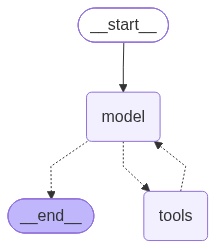

In [ ]:
from IPython.display import Image, display

display(Image(search_agent.get_graph().draw_mermaid_png()))

# **Step 4 - Design Your Agent State (Multiagent in Langgraph)**




## **Graph State**

In [ ]:
from typing import TypedDict, Annotated, List, Optional
import operator
from langchain.messages import AnyMessage

## **Task for Orchestrator Worker Pattern**

In [ ]:
class AgentTask(BaseModel):
    """A single agent task with targeted query."""
    source: Literal["search_agent_node", "planner_agent_node"] # Where to send it to
    user_query: str # Original user query
    focus: str = ""  # What aspect this agent should focus on: Search (Flights and Hotels) OR Scout Agent (Itinerary & General)

# For the same query "Plan me a trip to Tokyo next June under $3000 for 5 days"
```
AgentTask(source="search_agent_node",
          user_query="Plan me a trip to Tokyo next June under $3000",
          focus="flights JFK-NRT June, budget hotels under $150/night")

AgentTask(source="planner_agent_node",
          user_query="Plan me a trip to Tokyo next June under $3000",
          focus="5-day itinerary, cultural sites, food recommendations")

```




## **Main Graph State**

In [ ]:
##### MAIN GRAPH STATE ######

class TravelPlannerState(TypedDict):
    """Enhanced state for parallel execution."""

    # Conversation history => message_history
    messages: Annotated[List[AnyMessage], operator.add] #reducer

    # Current user query
    user_query: str

    # Tasks from router (replaces single classification)
    tasks: List[AgentTask]

    # Flag for synthesis
    requires_synthesis: bool

    # Parallel agent results - KEY: uses operator.add for concurrent writes
    agent_results: Annotated[List[dict], operator.add]

    # Final synthesized answer
    final_answer: str

    search_messages: Annotated[List[AnyMessage], operator.add]
    planner_messages: Annotated[List[AnyMessage], operator.add]

# **Step 5 - Build Your Nodes**

## Orchestrator


*  Breaks down tasks into subtasks
*  Delegates subtasks to workers/nodes


*   Synthesizes worker outputs into a final result

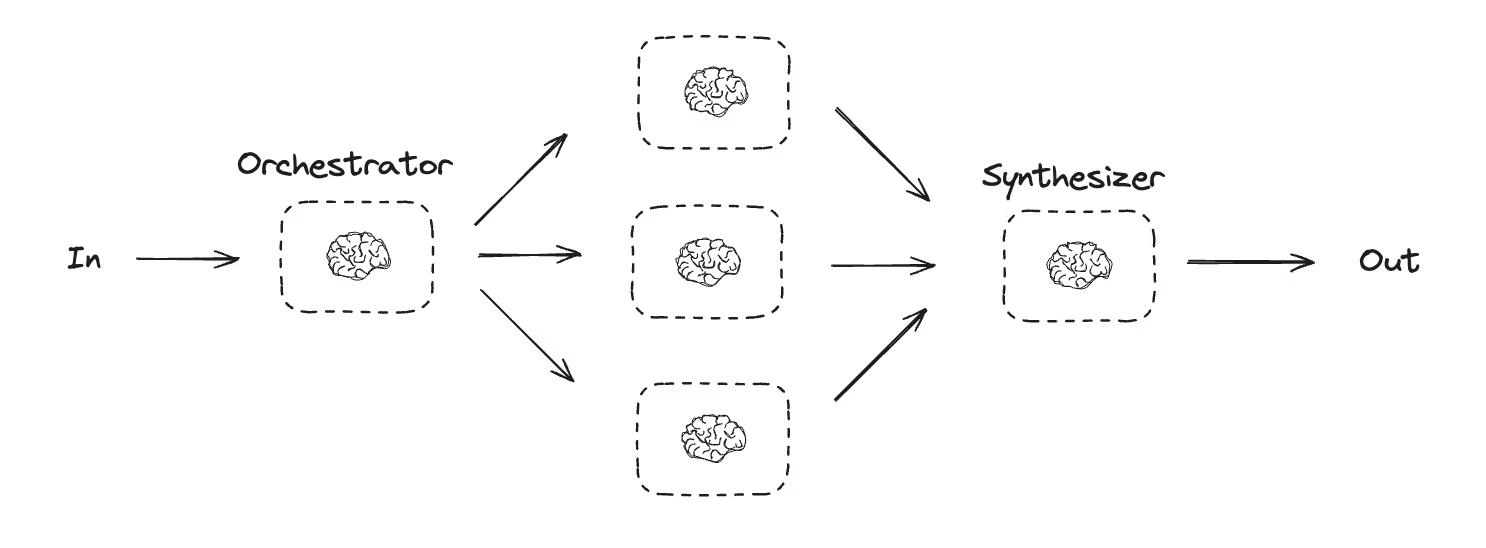






In [ ]:
from langgraph.types import Send
from langchain.messages import SystemMessage, ToolMessage, HumanMessage, AIMessage

In [ ]:
# STRUCTURED OUTPUT SCHEMA FOR ORCHESTRATOR

class ClassificationResult(BaseModel):
    """Router output - now supports MULTIPLE parallel tasks."""
    tasks: List[AgentTask] = Field(
        description="List of agents to invoke with their targeted queries"
    )
    requires_synthesis: bool = Field(
        default=False,
        description="Whether multiple agents are being used and synthesis is needed"
    )

Example:

```
ClassificationResult(
    tasks=[
        AgentTask(source="search_agent_node",
                  user_query="Find flights to Nairobi June 5-12 under $2500",
                  focus="flight options and prices"),
        AgentTask(source="planner_agent_node",
                  user_query="Plan a 7-day Nairobi itinerary",
                  focus="wildlife and Westlands food scene"),
    ],
    requires_synthesis=True
)
```



In [ ]:
# # WORKER/NODE STATE FOR INDIVIDUAL AGENTS (NOT BEING CURRENTLY USED)

# class AgentWorkerState(TypedDict):
#     """State passed to each parallel worker."""
#     task: AgentTask
#     messages: List[AnyMessage]
#     agent_results: Annotated[List[dict], operator.add]

### **Orchestrator**

In [ ]:
def classify_query_parallel(state: TravelPlannerState) -> dict: #node
    """
    Updated router that can dispatch to MULTIPLE agents.
    """
    router_llm = llm
    structured_llm = router_llm.with_structured_output(ClassificationResult)

    result = structured_llm.invoke([
        {
            "role": "system",
            "content": """ You are a Travel Request Router that can dispatch to MULTIPLE agents in parallel.

AVAILABLE AGENTS:
1. search_agent_node - Flight searches, hotel searches, pricing, availability
2. planner_agent_node - Itineraries, travel tips, weather, visas, activities, general guidance

ROUTING RULES:

SINGLE AGENT (requires_synthesis = false):
- Flight/hotel ONLY → search_agent_node
- Itinerary/planning ONLY → planner_agent_node
- General travel questions → planner_agent_node

MULTIPLE AGENTS (requires_synthesis = true):
- "Plan a trip AND find flights/hotels" → BOTH agents
- "Find hotels and create itinerary" → BOTH agents
- Requests mentioning BOTH booking AND planning → BOTH agents

When dispatching to BOTH agents:
1. Create a focused sub-query for each agent
2. search_agent_node query should focus on flights/hotels/pricing
3. planner_agent_node query should focus on itinerary/activities/tips

EXAMPLES:

Query: "Find flights from DEL to DXB"
→ tasks: [{"source": "search_agent_node", "user_query": "Find flights from DEL to DXB"}]
→ requires_synthesis: false

Query: "Plan a 5-day trip to Paris"
→ tasks: [{"source": "planner_agent_node", "user_query": "Plan a 5-day trip to Paris"}]
→ requires_synthesis: false

Query: "Plan a week in London and find me hotels under $200/night"
→ tasks: [
    {"source": "search_agent_node", "user_query": "Find hotels in London under $200/night for 1 week", "focus": "hotel search and pricing"},
    {"source": "planner_agent_node", "user_query": "Plan a week-long itinerary for London", "focus": "daily activities and attractions"}
  ]
→ requires_synthesis: true

Query: "I want to visit Tokyo - book flights from NYC and create a 5-day itinerary"
→ tasks: [
    {"source": "search_agent_node", "user_query": "Find flights from NYC to Tokyo", "focus": "flight options and prices"},
    {"source": "planner_agent_node", "user_query": "Create a 5-day itinerary for Tokyo", "focus": "daily schedule and activities"}
  ]
→ requires_synthesis: true """
        },
        {"role": "user", "content": state["user_query"]}
    ])

    return {
        "tasks": result.tasks,
        "requires_synthesis": result.requires_synthesis
    }


### **Dispatcher**

In [ ]:
from langgraph.types import Send

# Dispatch at most one worker per agent source. Multiple search tasks
# (for example, flights + hotels) are combined into one isolated worker.
def dispatch_to_agents(state: TravelPlannerState):
    grouped_tasks = {}

    for task in state.get("tasks", []):
        grouped_tasks.setdefault(task.source, []).append(task)

    sends = []

    for source, tasks_for_source in grouped_tasks.items():
        combined_query = (chr(10) * 2).join(
            f"- {task.user_query}" for task in tasks_for_source
        )

        worker_state = {
            "messages": state.get("messages", []),
            "user_query": combined_query,
            "tasks": tasks_for_source,
            "requires_synthesis": state.get("requires_synthesis", False),
            "agent_results": [],
            "final_answer": "",
            "search_messages": (
                [HumanMessage(content=combined_query)]
                if source == "search_agent_node"
                else []
            ),
            "planner_messages": (
                [HumanMessage(content=combined_query)]
                if source == "planner_agent_node"
                else []
            ),
        }

        sends.append(Send(source, worker_state))

    return sends

In [ ]:
# # #cleaner
# def dispatch_to_agents(state: TravelPlannerState):
#     sends = []
#     for task in state.get("tasks", []):
#         worker_state: AgentWorkerState = {
#             "task": task,
#             "messages": [],
#             "agent_results": [],
#         }
#         sends.append(Send(task.source, worker_state))
#     return sends

### **Synthesizer**

In [ ]:
# SYNTHESIZER

def synthesizer_node(state: TravelPlannerState) -> dict:
    """
    Combines results from parallel agents into a unified response.
    Only called when requires_synthesis is True.
    """

    agent_results = state.get("agent_results", [])


    if not agent_results:
        return {
            "final_answer": "I couldn't process your request.",
            "messages": [AIMessage(content="I couldn't process your request.")]
        }


    # If only one result, no synthesis needed
    if len(agent_results) == 1:
        result = agent_results[0]["result"]
        return {
            "final_answer": result,
            "messages": [AIMessage(content=result)] #operator.add
        }

    # Format results for synthesis
    # **SEARCH_AGENT**
    #  Focus: flights
    #  (flight results here)

    #  ==================================================

    #  **PLANNER_AGENT**
    #  Focus: itinerary
    #  (itinerary here)
    results_formatted = "\n\n" + "="*50 + "\n\n".join([
        f"**{r['agent'].upper()}**\nFocus: {r.get('focus', 'N/A')}\n\n{r['result']}"
        for r in agent_results
    ])

    synthesis_prompt = """You are a Travel Response Synthesizer. Combine multiple agent outputs into
a single, well-organized, comprehensive response.

RULES:
1. Organize logically (e.g., Flights → Hotels → Itinerary → Tips)
2. Don't repeat information
3. Highlight key recommendations
4. Note any conflicts or alternatives
5. Create clear sections with headers
6. End with actionable next steps

Original Query: {query}

Agent Results:
{results}

Create a unified, helpful response:"""

    response = llm.invoke([
        HumanMessage(content=synthesis_prompt.format(
            query=state["user_query"],
            results=results_formatted
        ))
    ])

    return {
        "final_answer": response.content,
        "messages": [AIMessage(content=response.content)]
    }

## Define Search (Flight & Hotel) and Planner (TravelScout & ItineraryResearch) Nodes

### Augment the LLM with tools

In [ ]:
print(search_tools)

[StructuredTool(name='search_flights', description='Search for flights between airports.', args_schema=<class '__main__.FlightSearchInput'>, func=<function search_flights at 0x7a4834c33ba0>), StructuredTool(name='search_hotels', description='Search for hotels in a location.', args_schema=<class '__main__.HotelSearchInput'>, func=<function search_hotels at 0x7a4834c30cc0>)]


In [ ]:
# Augment the LLM with tools / JSON schema / Tool Binding (LLM FOR THE SEARCH AGENT NODE)
search_tools_by_name = {tool.name: tool for tool in search_tools}

search_model_with_tools = llm.bind_tools(search_tools)

In [ ]:
# LLM FOR THE PLANNER AGENT NODE
planner_tools = [internet_search, call_itinerary_research_agent]

planner_model_with_tools = llm.bind_tools(planner_tools)

In [ ]:
print(planner_tools)

[TavilySearch(search_depth='advanced', include_images=True, max_results=5, topic='general', include_image_descriptions=True, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)), StructuredTool(name='itinerary_research_agent', description='plans travel itinerary', args_schema=<class 'langchain_core.utils.pydantic.itinerary_research_agent'>, func=<function call_itinerary_research_agent at 0x7a4834b6f100>)]


### Search Agent & Tool Node

In [ ]:
def search_agent_node(state: TravelPlannerState):
    """Search agent with its own message history"""

    # Use search-specific messages
    search_msgs = state.get("search_messages", []) #history messages = empty
    messages = [SystemMessage(content=flightHotelSearch_instructions)] + search_msgs

    # If this is first call, add the user query
    if not search_msgs:
        messages.append(HumanMessage(content=state.get("user_query", "")))

    response = search_model_with_tools.invoke(messages)
    # response.tool_calls

    return {
        "search_messages": [response], #use that reducer operator.add
        "agent_results": [{
            "agent": "search_agent",
            "focus": "flights and hotels",
            "result": response.content # llm responding
        }] if not response.tool_calls else [] #a message carrying tool_calls is not an answer — its .content is usually empty.
        # You only publish to agent_results when the agent actually stopped calling tools.
    }

In [ ]:
def search_tool_node(state: TravelPlannerState):
    """Execute search tools"""
    search_msgs = state.get("search_messages", [])

    if not search_msgs:
        return {"search_messages": []}

    last_message = search_msgs[-1]

    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return {"search_messages": []}

    result = []
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool = search_tools_by_name.get(tool_name)
        if tool:
            try:
                observation = tool.invoke(tool_call["args"])
                result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
            except Exception as e:
                # Catch exceptions during tool invocation and still return a ToolMessage
                error_content = json.dumps({"error": f"Tool {tool_name} failed with: {str(e)}"})
                result.append(ToolMessage(content=error_content, tool_call_id=tool_call["id"]))
                print(f"ERROR: Tool {tool_name} invocation failed for ID {tool_call['id']}: {e}")
        else:
            # If tool not found, still return a ToolMessage to satisfy the API
            missing_tool_error = f"ERROR: Tool '{tool_name}' not found in search_tools_by_name for tool_call_id: {tool_call['id']}"
            result.append(ToolMessage(content=json.dumps({"error": missing_tool_error}), tool_call_id=tool_call["id"]))
            print(missing_tool_error)

    return {"search_messages": result}

### Planner Agent & Tool Node

In [ ]:
def planner_agent_node(state: TravelPlannerState):
    """Planner agent with its own message history"""

    # Use planner-specific messages
    planner_msgs = state.get("planner_messages", [])

    messages = [SystemMessage(content=travel_scout_instructions)] + planner_msgs

    # If this is first call, add the user query
    if not planner_msgs:
        messages.append(HumanMessage(content=state.get("user_query", "")))

    response = planner_model_with_tools.invoke(messages)

    return {
        "planner_messages": [response],
        "agent_results": [{
            "agent": "planner_agent",
            "focus": "travel planning and itinerary",
            "result": response.content
        }] if not response.tool_calls else []
        # "messages": [planner_msgs]
    }

In [ ]:
def planner_tool_node(state: TravelPlannerState):
    """Execute planner tools"""
    planner_msgs = state.get("planner_messages", [])

    if not planner_msgs:
        return {"planner_messages": []}

    last_message = planner_msgs[-1]

    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return {"planner_messages": []}

    planner_tools_by_name = {tool.name: tool for tool in planner_tools}
    result = []

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool = planner_tools_by_name.get(tool_name)
        if tool:
            try:
                observation = tool.invoke(tool_call["args"])
                result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
            except Exception as e:
                error_content = json.dumps({"error": f"Tool {tool_name} failed with: {str(e)}"})
                result.append(ToolMessage(content=error_content, tool_call_id=tool_call["id"]))
                print(f"ERROR: Tool {tool_name} invocation failed for ID {tool_call['id']}: {e}")
        else:
            # If tool not found, still return a ToolMessage to satisfy the API
            missing_tool_error = f"ERROR: Tool '{tool_name}' not found in planner_tools_by_name for tool_call_id: {tool_call['id']}"
            result.append(ToolMessage(content=json.dumps({"error": missing_tool_error}), tool_call_id=tool_call["id"]))
            print(missing_tool_error)

    return {"planner_messages": result}

### Conditional Edges

In [ ]:
def should_continue_for_searchAgent(state: TravelPlannerState):
    search_msgs = state.get("search_messages", [])
    if search_msgs and hasattr(search_msgs[-1], 'tool_calls') and search_msgs[-1].tool_calls:
        return "search_tool_node"
    return "synthesizer"

In [ ]:
def should_continue_for_plannerAgent(state: TravelPlannerState):
    """Check if planner needs to continue tool loop"""
    planner_msgs = state.get("planner_messages", [])
    if planner_msgs and hasattr(planner_msgs[-1], 'tool_calls') and planner_msgs[-1].tool_calls:
        return "planner_tool_node"
    return "synthesizer"

# **Step 6 - Build & Compile Your Workflow**

In [ ]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

In [ ]:
def build_parallel_travel_agent():
    """Build the graph with parallel execution support."""

    builder = StateGraph(TravelPlannerState)

    # Add nodes
    builder.add_node("orchestrator", classify_query_parallel)
    builder.add_node("search_agent_node", search_agent_node)
    builder.add_node("planner_agent_node", planner_agent_node)
    builder.add_node("search_tool_node", search_tool_node)
    builder.add_node("planner_tool_node", planner_tool_node)
    builder.add_node("synthesizer", synthesizer_node)

    # Connect edges
    builder.add_edge(START, "orchestrator")

    # Router dispatches to agents via Send API (parallel execution)
    builder.add_conditional_edges(
        "orchestrator",
        dispatch_to_agents, #dispatcher fuction
        ["search_agent_node", "planner_agent_node"]
    )

    # Search agent tool loop
    builder.add_conditional_edges(
        "search_agent_node",
        should_continue_for_searchAgent,
        ["search_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("search_tool_node", "search_agent_node")

    # Planner agent tool loop
    builder.add_conditional_edges(
        "planner_agent_node",
        should_continue_for_plannerAgent,
        ["planner_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("planner_tool_node", "planner_agent_node")

    # End after synthesis
    builder.add_edge("synthesizer", END)

    return builder.compile()

In [ ]:
# Compile the agent
agent = build_parallel_travel_agent()

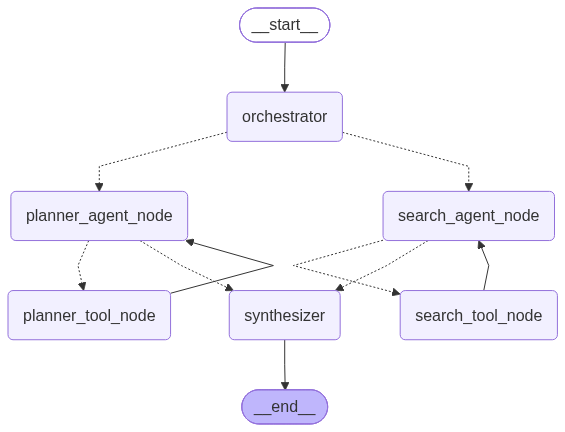

In [ ]:
# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

# **Step 7 - Test the Multi-Agent System**

1.   List item
2.   List item




### Test Multi-Agent Travel Planner

In [ ]:
# Regression test: duplicate router tasks must become one worker per source
regression_state = {
    "user_query": "flight + hotel + itinerary",
    "messages": [],
    "tasks": [
        AgentTask(source="search_agent_node", user_query="find flights", focus="flights"),
        AgentTask(source="search_agent_node", user_query="find hotels", focus="hotels"),
        AgentTask(source="planner_agent_node", user_query="plan itinerary", focus="itinerary"),
    ],
    "requires_synthesis": True,
    "agent_results": [],
    "final_answer": "",
    "search_messages": [],
    "planner_messages": [],
}

regression_sends = dispatch_to_agents(regression_state)
assert len(regression_sends) == 2, (
    f"Expected one worker per source (2 total), got {len(regression_sends)}"
)
print("PASS: dispatcher emits one worker per agent source")

PASS: dispatcher emits one worker per agent source


In [ ]:
agent = build_parallel_travel_agent()

config = {
    "configurable": {
        "thread_id": "samwel-clean-1"
    }
}

In [ ]:
result = agent.invoke({
        "user_query": "Plan a 5-day trip to Paris and find me flights from JFK to LHR for 1 adult only on 21 Jan 2026 (one way trip) & also let me know hotels for myself only (adult) from my lading to LHR to next day",
        "messages": []
    })

In [ ]:
# Print everything step by step
print("=" * 60)
print("USER QUERY:")
print(result["user_query"])

print("\n" + "=" * 60)
print("TASKS DISPATCHED:")
for task in result.get("tasks", []):
    print(f"  • {task.source}: {task.user_query}")

print("\n" + "=" * 60)
print("AGENT RESULTS:")
for r in result.get("agent_results", []):
    print(f"\n[{r['agent'].upper()}]")
    print("-" * 40)
    print(r["result"][:50000] + "..." if len(r["result"]) > 500 else r["result"])

print("\n" + "=" * 60)
print("FINAL SYNTHESIZED RESPONSE:")
print("=" * 60)
print(result["final_answer"])

USER QUERY:
Plan a 5-day trip to Paris and find me flights from JFK to LHR for 1 adult only on 21 Jan 2026 (one way trip) & also let me know hotels for myself only (adult) from my lading to LHR to next day

TASKS DISPATCHED:
  • search_agent_node: Find flights from JFK to LHR for 1 adult on 21 Jan 2026 (one way trip)
  • search_agent_node: Find hotels in London for 1 adult for 1 night after arriving from JFK to LHR
  • planner_agent_node: Plan a 5-day itinerary for Paris

AGENT RESULTS:

[PLANNER_AGENT]
----------------------------------------
To create a tailored 5-day itinerary for Paris, I need to know a bit more about your preferences. Here are some questions to help me design the best experience for you:

1. **Interests**: Are you more interested in art, history, food, shopping, or outdoor activities?
2. **Pace**: Do you prefer a relaxed pace with plenty of downtime, or do you want to see as much as possible?
3. **Accommodations**: Do you have a specific area in Paris where you’d 

# **Add Persistence**

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig

In [ ]:
def build_parallel_travel_agent():
    """Build the graph with parallel execution support."""

    builder = StateGraph(TravelPlannerState)

    # Add nodes
    builder.add_node("orchestrator", classify_query_parallel)
    builder.add_node("search_agent_node", search_agent_node)
    builder.add_node("planner_agent_node", planner_agent_node)
    builder.add_node("search_tool_node", search_tool_node)
    builder.add_node("planner_tool_node", planner_tool_node)
    builder.add_node("synthesizer", synthesizer_node)

    # Connect edges
    builder.add_edge(START, "orchestrator")

    # Router dispatches to agents via Send API (parallel execution)
    builder.add_conditional_edges(
        "orchestrator",
        dispatch_to_agents,
        ["search_agent_node", "planner_agent_node"]
    )

    # Search agent tool loop
    builder.add_conditional_edges(
        "search_agent_node",
        should_continue_for_searchAgent,
        ["search_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("search_tool_node", "search_agent_node")

    # Planner agent tool loop
    builder.add_conditional_edges(
        "planner_agent_node",
        should_continue_for_plannerAgent,
        ["planner_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("planner_tool_node", "planner_agent_node")

    # End after synthesis
    builder.add_edge("synthesizer", END)

    # Built-in Persistence
    checkpointer = InMemorySaver()

    return builder.compile(checkpointer=checkpointer)

In [ ]:
# Compile the agent
agent = build_parallel_travel_agent()

In [ ]:
config = {"configurable": {"thread_id": "samwel"}}
config2 = {"configurable": {"thread_id": "arun"}}
config3 = {"configurable": {"thread_id": "prasad"}}
sree = {"configurable": {"thread_id": "sree"}}

In [ ]:
result = agent.invoke(
    {
        "user_query": "What is the best time to visit Zanzibar?",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config #samwel's
)

print(result['final_answer'])

### Best Time to Visit Zanzibar

Zanzibar, known for its stunning beaches and rich culture, has a tropical climate with distinct wet and dry seasons. Here’s a breakdown of the best times to visit:

#### **Dry Season (June to October)**
- **Ideal Conditions**: This is the best time to visit Zanzibar. The weather is dry, with average temperatures ranging from 77°F to 82°F (25°C to 28°C).
- **Activities**: Perfect for beach activities, diving, and exploring Stone Town.
- **Crowds**: Expect more tourists, especially in July and August, as this period coincides with the safari high season in mainland Tanzania.

#### **Short Rainy Season (November to December)**
- **Weather**: Characterized by short, heavy showers, but still plenty of sunshine.
- **Pros**: Fewer crowds and often better deals on accommodations.
- **Activities**: Good for those looking to avoid the peak tourist season while still enjoying decent weather.

#### **Long Rainy Season (March to May)**
- **Conditions**: This period 

In [ ]:
result = agent.invoke(
    {
        "user_query": "Major historical sites there (must visit kind of)",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config
)

print(result['final_answer'])

# Travel Guide to Major Historical Sites in Zanzibar

Zanzibar, an archipelago off the coast of Tanzania, is renowned for its rich history, stunning architecture, and vibrant culture. Below is a comprehensive guide to help you plan your visit, focusing on historical sites, the best time to visit, and essential tips.

## Best Time to Visit

### **Dry Season (June to October)**
- **Ideal Conditions**: This is the best time to explore Zanzibar, with dry weather and temperatures ranging from 77°F to 82°F (25°C to 28°C).
- **Activities**: Perfect for visiting historical sites like Stone Town and enjoying beach activities.

### **Short Rainy Season (November to December)**
- **Weather**: Expect short, heavy showers but still plenty of sunshine.
- **Pros**: Fewer tourists and better accommodation deals.

### **Long Rainy Season (March to May)**
- **Conditions**: Heavy rainfall, especially in April and May, which may limit outdoor activities.
- **Travel Tips**: Lower prices but be prepared for

In [ ]:
result = agent.invoke(
    {
        "user_query": "What all cities I can cover along with this tour (in nearby which should not take more than 2-3 days extra)",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config # no history
)

print(result['final_answer'])

# Travel Planning for Zanzibar and Nearby Cities

## Flights
When planning your trip to Zanzibar, consider flying into Abeid Amani Karume International Airport (ZNZ), which is the main airport serving the island. Look for flights that align with the best travel seasons to maximize your experience.

## Hotels
Zanzibar offers a variety of accommodation options ranging from luxury resorts to budget-friendly guesthouses. Key areas to consider for your stay include:
- **Stone Town**: Ideal for cultural immersion and historical exploration.
- **Nungwi and Kendwa**: Known for stunning beaches and vibrant nightlife.
- **Paje**: Great for water sports and a more laid-back atmosphere.

### Key Recommendations
- **Book in advance** during the dry season (June to October) to secure the best rates and availability.
- Look for hotels that offer package deals including meals and activities.

## Itinerary Suggestions
If you have an additional 2-3 days to explore nearby cities, consider the following o